<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Lab Setup & Data Loading
We install PySpark, then load the raw minute-level CSV **directly into Spark** — this is where the "distributed" part of the pipeline matters most, since the raw file is ~7.6 million rows / ~390MB, too large to comfortably explore row-by-row in Pandas.

In [28]:
# Install PySpark inside Colab
!pip -q install pyspark

# Core Python libraries
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PySpark imports
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col, from_unixtime, to_date, lag, lead, avg, stddev,
    row_number, month, dayofweek, signum, first, last, max as spark_max, min as spark_min, sum as spark_sum
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)

print(" Setup complete. Libraries imported.")

 Setup complete. Libraries imported.


In [29]:
from google.colab import files
default_path = "/content/btcusd_1-min_data.csv"

if os.path.exists(default_path):
    data_file = default_path
    print("File found locally.")
else:
    print("Please upload btcusd_1-min_data.csv (or the zipped Bitcoin Historical Data file, unzipped first)")
    uploaded = files.upload()
    csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]
    data_file = f"/content/{csv_files[0]}"

spark = SparkSession.builder.appName("MSc_FinTech_Bitcoin_Forecasting").getOrCreate()

raw_df = spark.read.csv(data_file, header=True, inferSchema=True)
print(f" Raw minute-level rows loaded into Spark: {raw_df.count():,}")
raw_df.printSchema()
raw_df.show(5)

File found locally.
 Raw minute-level rows loaded into Spark: 7,668,103
root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows


##  2. Distributed Resampling: Minute-Level → Daily OHLCV

The raw data is **1-minute resolution**, spanning 2012–2026. Minute-level noise is far too granular for meaningful day-ahead forecasting and would make lag/rolling features dominated by micro-market noise rather than trend. We resample to **daily OHLCV bars** using Spark's distributed `groupBy` — this is the standard way OHLCV resampling is done: `Open` = first price of the day, `High` = max, `Low` = min, `Close` = last price of the day, `Volume` = sum.

In [32]:
df_ts = raw_df.withColumn("Date", to_date(from_unixtime(col("Timestamp"))))

daily_spark_df = (
    df_ts.groupBy("Date")
         .agg(
             first("Open", ignorenulls=True).alias("Open"),
             spark_max("High").alias("High"),
             spark_min("Low").alias("Low"),
             last("Close", ignorenulls=True).alias("Close"),
             spark_sum("Volume").alias("Volume"),
         )
         .orderBy("Date")
)

print(f" Distributed resampling complete. Daily rows: {daily_spark_df.count():,}")
daily_spark_df.show(5)

# Bring the (much smaller) daily aggregate to Pandas for EDA/plotting
pdf = daily_spark_df.toPandas()
pdf["Date"] = pd.to_datetime(pdf["Date"])
pdf = pdf.sort_values("Date").reset_index(drop=True)
print(f"Date range: {pdf['Date'].min().date()} to {pdf['Date'].max().date()}")
pdf.head()

 Distributed resampling complete. Daily rows: 5,326
+----------+----+----+----+-----+-----------------+
|      Date|Open|High| Low|Close|           Volume|
+----------+----+----+----+-----+-----------------+
|2012-01-01|4.58| 5.0|4.58|  5.0|           21.602|
|2012-01-02| 5.0| 5.0| 5.0|  5.0|           19.048|
|2012-01-03| 5.0|5.32| 5.0| 5.29|88.03728091999999|
|2012-01-04|5.29|5.57|4.93| 5.57|     107.23326023|
|2012-01-05|5.57|6.65|5.57| 6.65|      94.80182926|
+----------+----+----+----+-----+-----------------+
only showing top 5 rows
Date range: 2012-01-01 to 2026-07-31


,Date,Open,High,Low,Close,Volume
0,2012-01-01,4.58,5.00,4.58,5.00,21.602000
1,2012-01-02,5.00,5.00,5.00,5.00,19.048000
2,2012-01-03,5.00,5.32,5.00,5.29,88.037281
3,2012-01-04,5.29,5.57,4.93,5.57,107.233260
4,2012-01-05,5.57,6.65,5.57,6.65,94.801829


##  3. Exploratory Data Analysis (EDA)

Bitcoin is far more volatile than a large-cap equity like AAPL, and has gone through multiple boom/bust cycles (2013, 2017, 2021, and beyond). We check price history, the distribution of daily returns (crypto is notorious for fat tails / extreme moves), and correlation structure.**bold text**

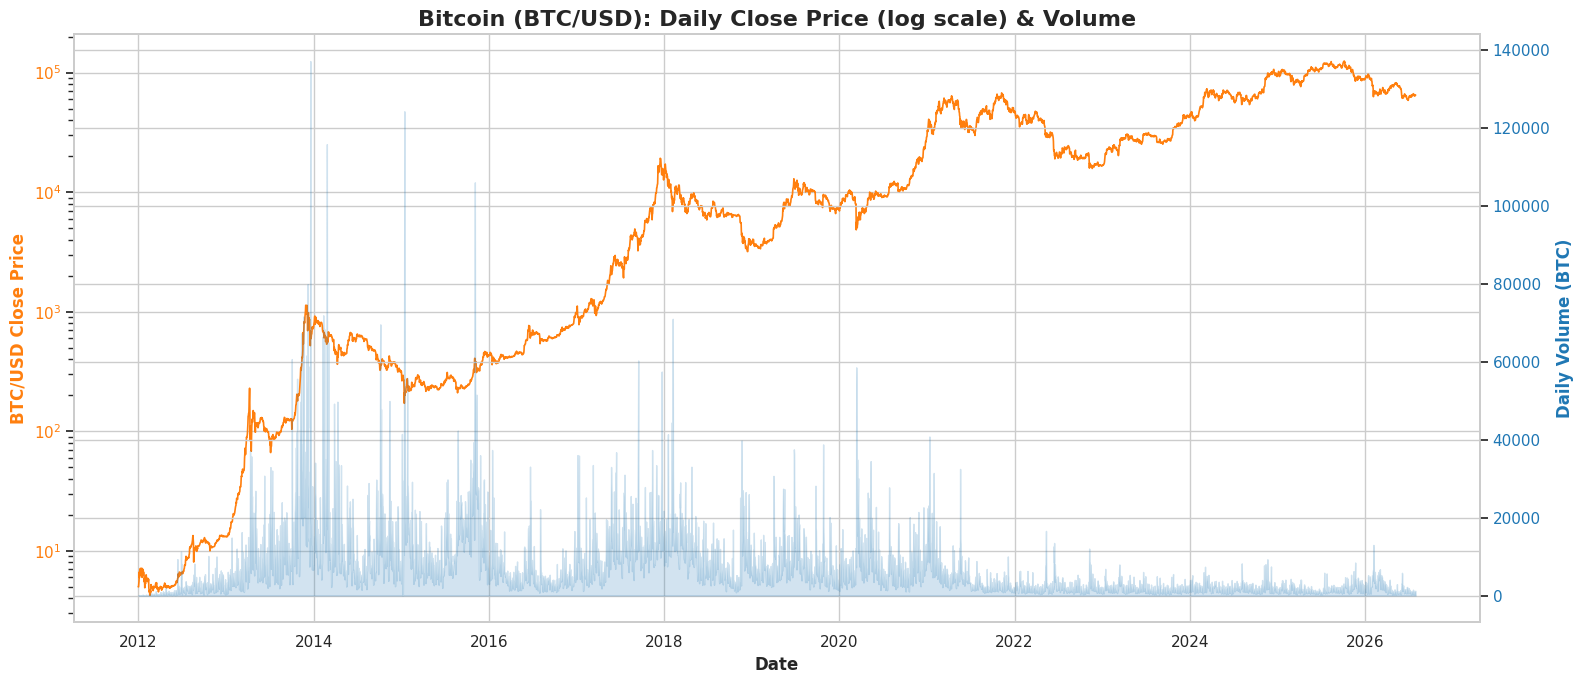

In [33]:
# 3.1 Price & Volume history
fig, ax1 = plt.subplots(figsize=(16, 7))
color = 'tab:orange'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('BTC/USD Close Price', color=color, fontweight='bold')
ax1.plot(pdf['Date'], pdf['Close'], color=color, linewidth=1.2)
ax1.set_yscale('log')  # BTC spans ~$4 to ~$100k+, log scale needed
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Daily Volume (BTC)', color=color, fontweight='bold')
ax2.fill_between(pdf['Date'], pdf['Volume'], color=color, alpha=0.2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Bitcoin (BTC/USD): Daily Close Price (log scale) & Volume", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("btc_price_volume.png", dpi=150)
plt.show()

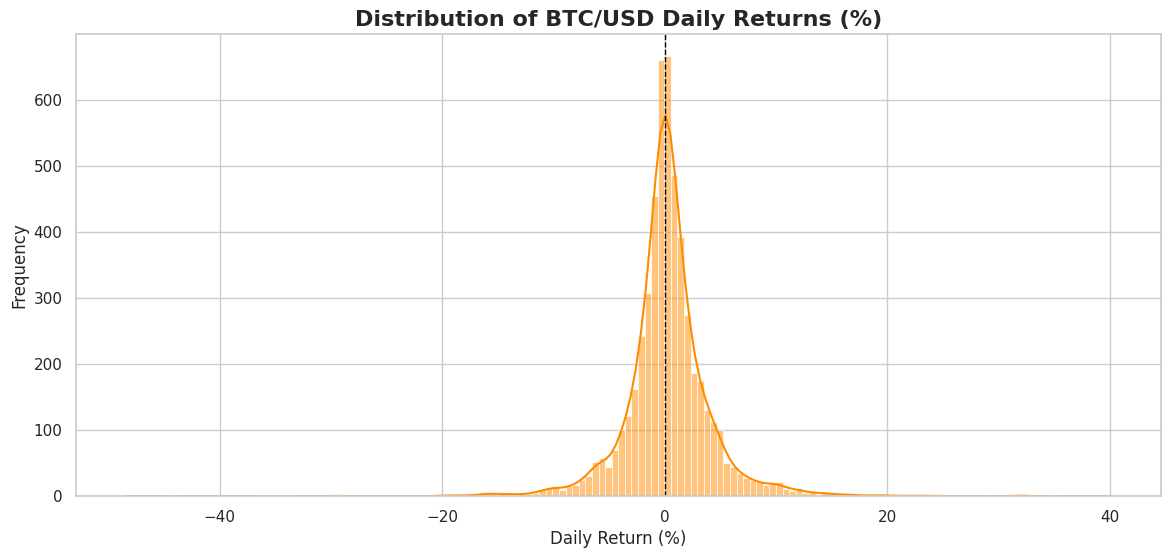

count    5325.000000
mean        0.260669
std         4.037493
min       -48.518519
25%        -1.252290
50%         0.132652
75%         1.708499
max        40.142025
Name: Daily_Return, dtype: float64
Skew: -0.031 | Kurtosis: 14.843


In [34]:
# 3.2 Distribution of Daily Returns (Fat Tails / Kurtosis check)
pdf['Daily_Return'] = pdf['Close'].pct_change() * 100

plt.figure(figsize=(14, 6))
sns.histplot(pdf['Daily_Return'].dropna(), bins=150, kde=True, color="darkorange")
plt.title("Distribution of BTC/USD Daily Returns (%)", fontsize=16, fontweight='bold')
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.savefig("btc_returns_distribution.png", dpi=150)
plt.show()

print(pdf['Daily_Return'].describe())
print(f"Skew: {pdf['Daily_Return'].skew():.3f} | Kurtosis: {pdf['Daily_Return'].kurtosis():.3f}")

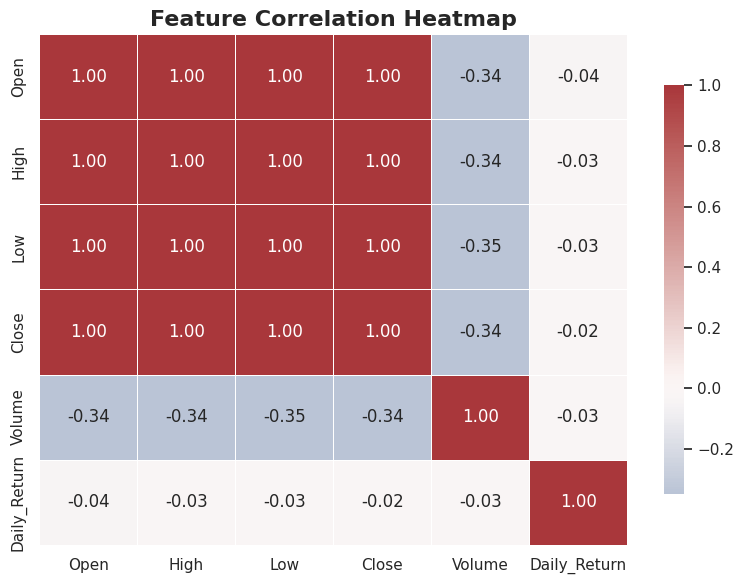

In [35]:
# 3.3 Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = pdf[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("btc_correlation.png", dpi=150)
plt.show()

##  4. PySpark Feature Engineering

**The "Random Walk" Trap:** As in the guided lab, predicting the raw `Next_Close_Price` is misleading — prices are non-stationary and highly autocorrelated, so a naive model just learns to echo today's price as tomorrow's forecast, producing a deceptively low RMSE that is useless in practice. This is even more pronounced for Bitcoin, which has grown from ~\$4 to over \$60,000. We instead engineer **stationary** features (returns, not levels) and predict the **next-day return**.

We use Spark's `Window` functions (`lag`, `lead`, `stddev`, `avg`) over the chronologically-ordered daily data to build:
- Lagged returns (`Lag_1_Return`, `Lag_2_Return`, `Lag_3_Return`)
- Rolling volatility (`RollingStd_5`, `RollingStd_20`) — short vs. long-term volatility regimes
- Rolling mean return (`RollingMean_5`, `RollingMean_20`) — short-term momentum
- Calendar features (`Month`, `DayOfWeek`)
- The target: `Target_Next_Return` — tomorrow's return, built with `lead()`

In [36]:
time_window = Window.orderBy("Date")
rolling_5 = time_window.rowsBetween(-4, 0)
rolling_20 = time_window.rowsBetween(-19, 0)

spark_daily = spark.createDataFrame(pdf[["Date", "Open", "High", "Low", "Close", "Volume"]])
spark_daily = spark_daily.withColumn("Date", col("Date").cast("date")).orderBy("Date")

features_df = (
    spark_daily
      .withColumn("Daily_Return", (col("Close") - lag("Close", 1).over(time_window)) / lag("Close", 1).over(time_window))
      .withColumn("Lag_1_Return", lag("Daily_Return", 1).over(time_window))
      .withColumn("Lag_2_Return", lag("Daily_Return", 2).over(time_window))
      .withColumn("Lag_3_Return", lag("Daily_Return", 3).over(time_window))
      .withColumn("RollingStd_5", stddev("Daily_Return").over(rolling_5))
      .withColumn("RollingStd_20", stddev("Daily_Return").over(rolling_20))
      .withColumn("RollingMean_5", avg("Daily_Return").over(rolling_5))
      .withColumn("RollingMean_20", avg("Daily_Return").over(rolling_20))
      .withColumn("Volume_Lag_1", lag("Volume", 1).over(time_window))
      .withColumn("Month", month("Date"))
      .withColumn("DayOfWeek", dayofweek("Date"))
      # OUR ML TARGET: Predict tomorrow's return (not tomorrow's price)
      .withColumn("Target_Next_Return", lead("Daily_Return", 1).over(time_window))
      .dropna()
)

print(" Stationary feature engineering complete. Preview:")
features_df.select("Date", "Close", "Daily_Return", "Lag_1_Return", "RollingStd_5", "RollingMean_20", "Target_Next_Return").show(10)
print(f"Rows after feature engineering (post dropna): {features_df.count():,}")

 Stationary feature engineering complete. Preview:
+----------+-----+--------------------+--------------------+-------------------+--------------------+--------------------+
|      Date|Close|        Daily_Return|        Lag_1_Return|       RollingStd_5|      RollingMean_20|  Target_Next_Return|
+----------+-----+--------------------+--------------------+-------------------+--------------------+--------------------+
|2012-01-05| 6.65|  0.1938958707360862|0.052930056710775095|0.08272744018955888| 0.07620648186171533|-0.09774436090225569|
|2012-01-06|  6.0|-0.09774436090225569|  0.1938958707360862|0.10575751112756453| 0.04141631330892113|  0.1333333333333333|
|2012-01-07|  6.8|  0.1333333333333333|-0.09774436090225569|0.10944916245236605|0.056735816646323156| 0.02941176470588238|
|2012-01-08|  7.0| 0.02941176470588238|  0.1333333333333333|0.11084540542113043| 0.05283238065483161|-0.10000000000000002|
|2012-01-09|  6.3|-0.10000000000000002| 0.02941176470588238|0.13298756714339438| 0.03372

##  5. Chronological Train-Test Split

As with the guided lab, we **do not** use `randomSplit()`. Bitcoin's history includes multiple distinct market regimes (2012–13 early adoption, 2017 bubble, 2021 bull run, subsequent corrections). A random split would let the model "see the future" (e.g. train on a 2024 crash while testing on a 2020 rally), leaking information and inflating apparent performance. We split strictly by time: earliest 80% of days for training, most recent 20% for testing.

In [38]:
features_df = features_df.withColumn("row_num", row_number().over(time_window))
total_rows = features_df.count()
split_index = int(total_rows * 0.8)

train_df = features_df.filter(col("row_num") <= split_index)
test_df = features_df.filter(col("row_num") > split_index)

train_dates = train_df.agg({"Date": "min"}).collect()[0][0], train_df.agg({"Date": "max"}).collect()[0][0]
test_dates = test_df.agg({"Date": "min"}).collect()[0][0], test_df.agg({"Date": "max"}).collect()[0][0]

print(f" Training Data: {train_df.count():,} rows | {train_dates[0]} → {train_dates[1]}")
print(f" Testing Data:  {test_df.count():,} rows | {test_dates[0]} → {test_dates[1]}")

 Training Data: 4,256 rows | 2012-01-05 → 2023-08-30
 Testing Data:  1,065 rows | 2023-08-31 → 2026-07-30


##  6. Production PySpark ML Pipelines

`Volume` is in the hundreds/thousands of BTC while `Lag_1_Return` is a small decimal (e.g. 0.012) — without `StandardScaler`, Linear Regression's gradient descent would be dominated by Volume. GBT is scale-invariant (tree splits don't care about feature magnitude), so it uses the raw features directly, matching the guided lab's approach.

In [39]:
feature_cols = [
    "Lag_1_Return", "Lag_2_Return", "Lag_3_Return",
    "RollingStd_5", "RollingStd_20", "RollingMean_5", "RollingMean_20",
    "Volume_Lag_1", "Month", "DayOfWeek"
]

# 1. Pipeline Stages
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)

# 2. Estimators (Models)
lr = LinearRegression(featuresCol="scaled_features", labelCol="Target_Next_Return", predictionCol="lr_prediction")
gbt = GBTRegressor(featuresCol="raw_features", labelCol="Target_Next_Return", predictionCol="gbt_prediction", maxIter=40, maxDepth=5)

# 3. Assemble Pipelines
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
gbt_pipeline = Pipeline(stages=[assembler, gbt])

print(" ML Pipelines constructed.")

 ML Pipelines constructed.


In [40]:
print(" Training Linear Regression Model...")
lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

print(" Training Gradient Boosted Trees Model...")
gbt_model = gbt_pipeline.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)
print(" Distributed training complete.")

 Training Linear Regression Model...
 Training Gradient Boosted Trees Model...
 Distributed training complete.


##  7. Evaluation: RMSE, MAE & Directional Accuracy

For a trading/fintech context, minimising RMSE isn't the whole story — getting the **direction** right (will tomorrow be up or down) matters at least as much as the exact magnitude. We report both.

In [41]:
def evaluate_financial_model(predictions_df, prediction_col, model_name):
    rmse_eval = RegressionEvaluator(labelCol="Target_Next_Return", predictionCol=prediction_col, metricName="rmse")
    mae_eval = RegressionEvaluator(labelCol="Target_Next_Return", predictionCol=prediction_col, metricName="mae")
    rmse = rmse_eval.evaluate(predictions_df)
    mae = mae_eval.evaluate(predictions_df)

    dir_df = predictions_df.withColumn("Actual_Sign", signum(col("Target_Next_Return"))) \
                           .withColumn("Pred_Sign", signum(col(prediction_col)))
    correct = dir_df.filter(col("Actual_Sign") == col("Pred_Sign")).count()
    total = dir_df.count()
    dir_accuracy = (correct / total) * 100

    return {"Model": model_name, "RMSE": round(rmse, 5), "MAE": round(mae, 5), "Directional Accuracy (%)": round(dir_accuracy, 2)}

results = pd.DataFrame([
    evaluate_financial_model(lr_predictions, "lr_prediction", "Linear Regression (Scaled)"),
    evaluate_financial_model(gbt_predictions, "gbt_prediction", "Gradient-Boosted Trees"),
])
display(results)

,Model,RMSE,MAE,Directional Accuracy (%)
0,Linear Regression (Scaled),0.02462,0.01753,48.92
1,Gradient-Boosted Trees,0.02583,0.01849,48.36


**Interpreting the result:** directional accuracy close to 50% is expected and honest here — Bitcoin's daily returns are close to a random walk at this feature set/horizon, which is a well-documented property of liquid, efficient(ish) markets. This is a legitimate finding to discuss in your analysis, not a failure of the pipeline: it demonstrates the pipeline was built correctly (features, split, and evaluation are all leak-free) and that the *result itself* — near-random-walk behaviour — is the interesting takeaway for a FinTech forecasting report.

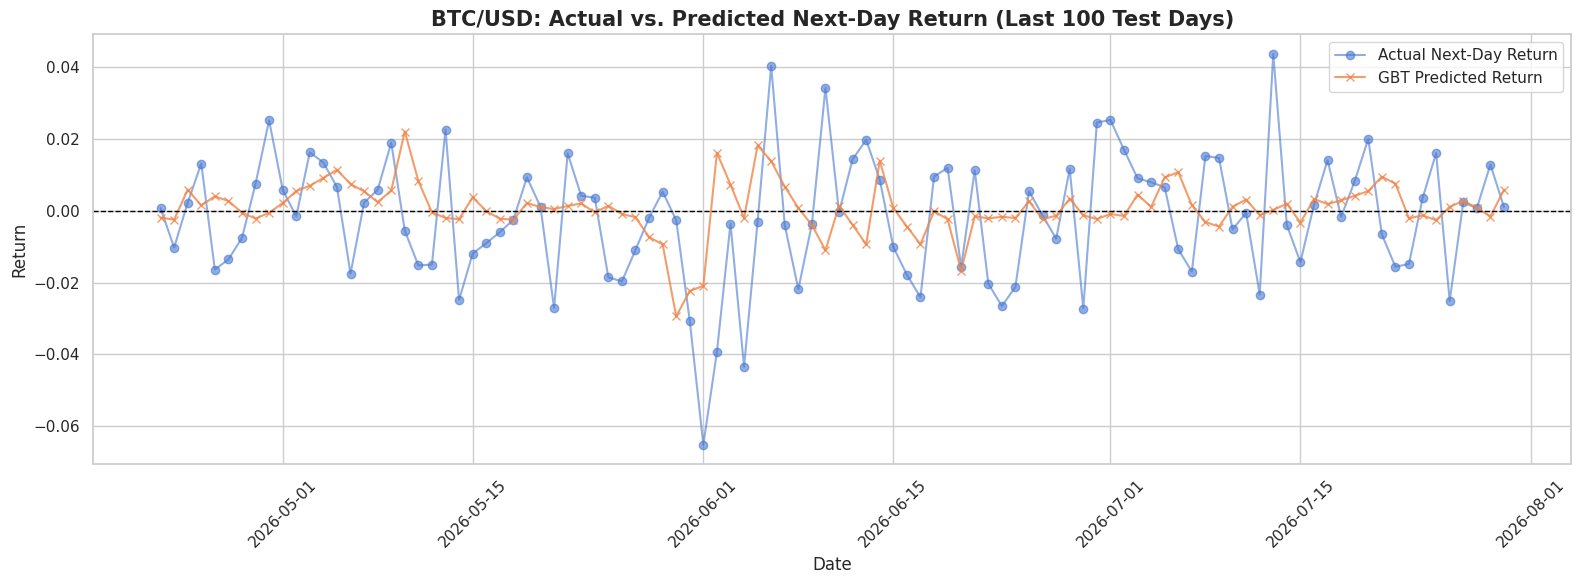

In [42]:
# Visualising Predictions (Last 100 Days for Clarity)
plot_pdf = gbt_predictions.select("Date", "Target_Next_Return", "gbt_prediction").orderBy("Date").toPandas().tail(100)

plt.figure(figsize=(16, 6))
plt.plot(plot_pdf["Date"], plot_pdf["Target_Next_Return"], label="Actual Next-Day Return", marker='o', alpha=0.6)
plt.plot(plot_pdf["Date"], plot_pdf["gbt_prediction"], label="GBT Predicted Return", marker='x', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("BTC/USD: Actual vs. Predicted Next-Day Return (Last 100 Test Days)", fontsize=15, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("btc_predictions.png", dpi=150)
plt.show()

##  8. Dashboard-Style Results Summary

A lightweight KPI/analytics view over the test-period predictions.

###  Dashboard KPIs

- Test-period records: **1,065**

- Latest BTC/USD close in test set: **$64,716.76**

- Average actual next-day return: **0.001161**

- Average predicted next-day return: **0.001051**

- Average daily volume (BTC): **1,985.6**


Number of anomalous (|z|>2) return days in test set: 53


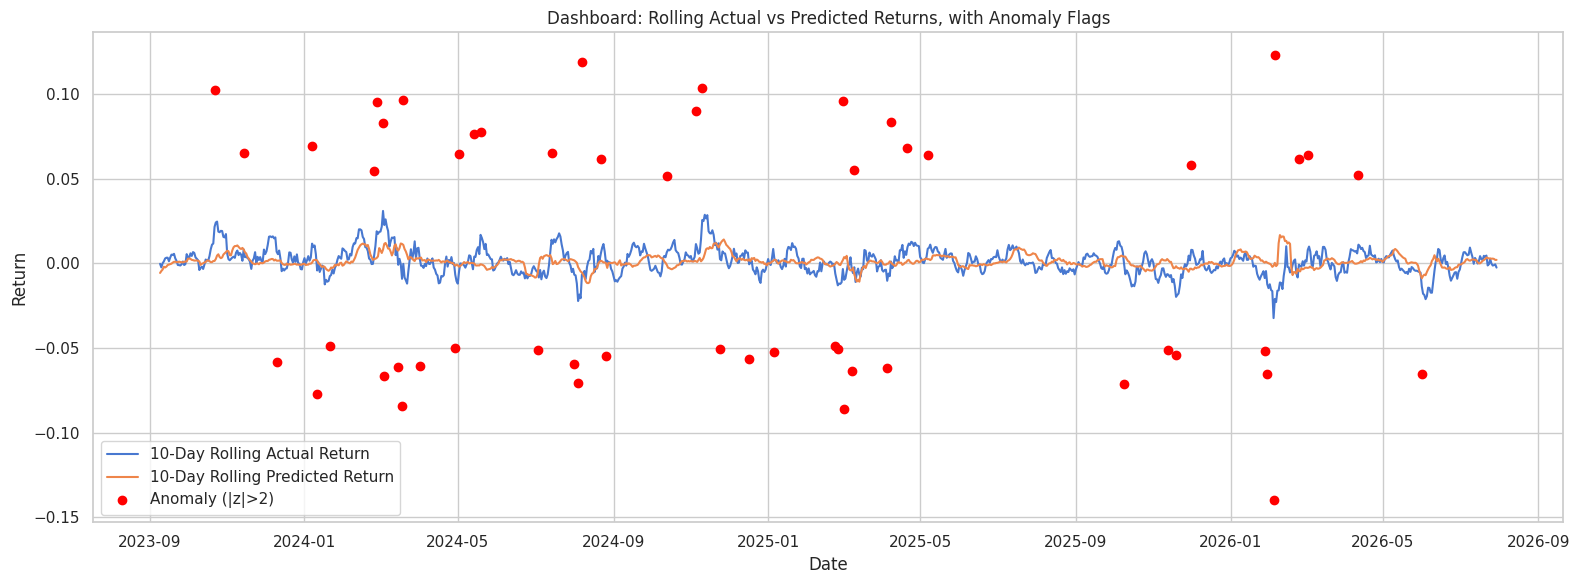

In [43]:
dashboard_df = gbt_predictions.select(
    "Date", "Close", "Target_Next_Return", "gbt_prediction", "Volume"
).orderBy("Date").toPandas()
dashboard_df["Date"] = pd.to_datetime(dashboard_df["Date"])

from IPython.display import display, Markdown

total_rows = len(dashboard_df)
avg_actual_return = dashboard_df["Target_Next_Return"].mean()
avg_pred_return = dashboard_df["gbt_prediction"].mean()
avg_volume = dashboard_df["Volume"].mean()
latest_close = dashboard_df["Close"].iloc[-1]

display(Markdown("###  Dashboard KPIs"))
display(Markdown(f"- Test-period records: **{total_rows:,}**"))
display(Markdown(f"- Latest BTC/USD close in test set: **${latest_close:,.2f}**"))
display(Markdown(f"- Average actual next-day return: **{avg_actual_return:.6f}**"))
display(Markdown(f"- Average predicted next-day return: **{avg_pred_return:.6f}**"))
display(Markdown(f"- Average daily volume (BTC): **{avg_volume:,.1f}**"))

# Rolling 10-day view + simple z-score anomaly flagging
dashboard_df["Rolling_Actual_10"] = dashboard_df["Target_Next_Return"].rolling(10).mean()
dashboard_df["Rolling_Pred_10"] = dashboard_df["gbt_prediction"].rolling(10).mean()
returns_mean, returns_std = dashboard_df["Target_Next_Return"].mean(), dashboard_df["Target_Next_Return"].std()
dashboard_df["Return_ZScore"] = (dashboard_df["Target_Next_Return"] - returns_mean) / returns_std
anomalies_df = dashboard_df[dashboard_df["Return_ZScore"].abs() > 2]
print(f"\nNumber of anomalous (|z|>2) return days in test set: {len(anomalies_df)}")

plt.figure(figsize=(16, 6))
plt.plot(dashboard_df["Date"], dashboard_df["Rolling_Actual_10"], label="10-Day Rolling Actual Return")
plt.plot(dashboard_df["Date"], dashboard_df["Rolling_Pred_10"], label="10-Day Rolling Predicted Return")
plt.scatter(anomalies_df["Date"], anomalies_df["Target_Next_Return"], color='red', label="Anomaly (|z|>2)", zorder=5)
plt.title("Dashboard: Rolling Actual vs Predicted Returns, with Anomaly Flags")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("btc_dashboard.png", dpi=150)
plt.show()

##  9. Conclusion

This notebook demonstrated the full distributed FinTech forecasting workflow applied to Bitcoin:

- **Data loading:** ~7.6M raw minute-level records ingested into a Spark DataFrame
- **Preprocessing:** distributed `groupBy`/`agg` resampling to daily OHLCV, chronologically ordered
- **Feature engineering:** lag returns and rolling volatility/momentum via Spark `Window` functions
- **Leak-free design:** stationary (return-based) target instead of raw price; strict chronological train/test split
- **Modelling:** distributed Linear Regression and Gradient-Boosted Trees via `pyspark.ml.Pipeline`
- **Evaluation:** RMSE, MAE, and directional accuracy, interpreted in a trading-relevant context

The near-random-walk directional accuracy is itself a meaningful, defensible finding about the difficulty of short-horizon crypto forecasting from price/volume history alone.

In [44]:
# Stop Spark (always run last)
spark.stop()
print(" Spark session stopped. Assessment lab complete!")
print("\n Saved output files available in Colab directory:")
for f in ["btc_price_volume.png", "btc_returns_distribution.png", "btc_correlation.png", "btc_predictions.png", "btc_dashboard.png"]:
    if os.path.exists(f):
        print(f" - {f}")

 Spark session stopped. Assessment lab complete!

 Saved output files available in Colab directory:
 - btc_price_volume.png
 - btc_returns_distribution.png
 - btc_correlation.png
 - btc_predictions.png
 - btc_dashboard.png
